In [99]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [100]:
df= pd.read_csv(r"C:\Users\himan\Education1\Projects\NLP\data\questions.csv")
df.shape

(404351, 6)

In [101]:
df.sample(10)

,id,qid1,qid2,question1,question2,is_duplicate
302021,302021,593127,593128,I intend to use a microcontroller (AVR) to des...,Which model of WD TV live is best?,0
14167,14167,28282,28283,What are some examples of bad design?,What are some examples of products that have b...,0
351160,351160,687920,687921,What is it like to date a Dominican man?,How do I get a man that is out of my league?,0
177045,177045,349746,349747,How will demonitization stop black money?,Is money demonetisation really working for bla...,1
341529,341529,669441,669442,How do I build a multistorey house?,How do I build a house?,0
252018,252018,496146,496147,Do hispanic men date black women?,What should white men do to date black women?,0
270895,270895,532788,532789,How many times do women orgasm during sex?,How many times can women reach orgasm in a hou...,1
284939,284939,560017,560018,How is science and Sanatana Dharma related?,How are Sanatana Dharma and science related?,1
154716,154716,305993,305994,How many start-ups are there in the Gurgaon?,How many start-ups can you do?,0
340646,340646,667739,42146,What are the best responses when someone tries...,"Superheroes: Who's better: Batman or Superman,...",0


In [102]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 404351 entries, 0 to 404350
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   id            404351 non-null  int64
 1   qid1          404351 non-null  int64
 2   qid2          404351 non-null  int64
 3   question1     404350 non-null  str  
 4   question2     404349 non-null  str  
 5   is_duplicate  404351 non-null  int64
dtypes: int64(4), str(2)
memory usage: 18.5 MB


In [103]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [104]:
df.duplicated().sum()

np.int64(0)

is_duplicate
0    255045
1    149306
Name: count, dtype: int64
is_duplicate
0    63.07515
1    36.92485
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

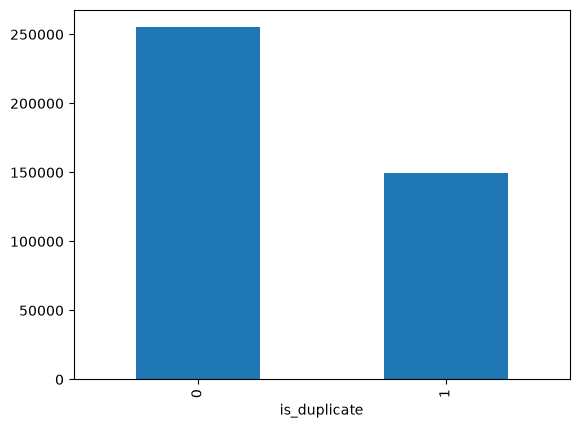

In [105]:
print(df['is_duplicate'].value_counts())
print((df['is_duplicate'].value_counts()/df['is_duplicate'].count())*100)
df['is_duplicate'].value_counts().plot(kind='bar')

In [106]:
qid = pd.Series(df['qid1'].tolist() + df['qid2'].tolist())
print('Number of unique questions',np.unique(qid).shape[0])
x = qid.value_counts()>1
print('Number of questions getting repeated',x[x].shape[0])

Number of unique questions 789801
Number of questions getting repeated 13698


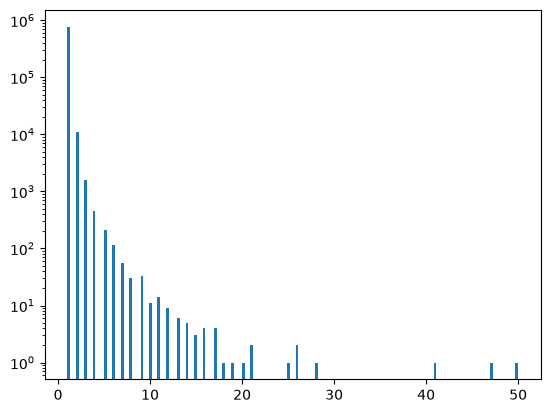

In [107]:
plt.hist(qid.value_counts().values,bins=160)
plt.yscale('log')
plt.show()

In [108]:
new_df = df.sample(50000)

In [109]:
new_df.duplicated().sum()

np.int64(0)

In [110]:
new_df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [111]:
ques_df = new_df[['question1','question2']]
ques_df.head() 

,question1,question2
29642,What are the top 5 most dangerous cities in th...,What are the most dangerous US cities? Why are...
330510,How can Hillary Clinton be allowed to take mon...,Should we be concerned that Hillary Clinton go...
84867,What if someone mistakenly has not mentioned f...,My father's annual income is 8 lakh. He is a g...
238929,When companies outsource high ranking position...,Do founders need to be located in the same off...
358803,How did the Kardashian family get famous?,"Who is more famous, Kim Kardashian or Kanye West?"


In [112]:
from sklearn.feature_extraction.text import CountVectorizer
# merge texts
questions = list(ques_df['question1']) + list(ques_df['question2'])



In [113]:
questions

['What are the top 5 most dangerous cities in the United States? How did they become so dangerous?',
 'How can Hillary Clinton be allowed to take money from foreign governments?',
 'What if someone mistakenly has not mentioned father government service income in obc form?',
 'When companies outsource high ranking positions to third world locations, do they face skill shortage?',
 'How did the Kardashian family get famous?',
 'What is option trading?',
 'Which is a suitable solar panel installation provider in Riverdale, California CA?',
 'How likely is a false negative pregnancy test two days before a due period?',
 'Just finished my PhD and am getting rejected from every job I apply for. What am I doing wrong?',
 'How can I make people want to be with me?',
 'How can one boost his/her CAT score?',
 'What would happen if Microsoft suddenly went bankrupt?',
 'What is a book that you can read over and over?',
 'How do you live your life?',
 'What are the safety precautions on handling sh

In [114]:
import tqdm
cv = CountVectorizer(max_features=3000)
q1_arr, q2_arr = np.vsplit(cv.fit_transform(questions).toarray(),2)

In [115]:
temp_df1 = pd.DataFrame(q1_arr, index= ques_df.index)
temp_df2 = pd.DataFrame(q2_arr, index= ques_df.index)
temp_df = pd.concat([temp_df1, temp_df2], axis=1)
temp_df.shape

(50000, 6000)

In [116]:
temp_df

,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
29642,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
330510,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
84867,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
238929,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
358803,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177124,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
16195,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
97260,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
97684,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [117]:
temp_df['is_duplicate'] = new_df['is_duplicate']

In [118]:
temp_df

,0,1,2,3,4,5,6,7,8,9,...,2991,2992,2993,2994,2995,2996,2997,2998,2999,is_duplicate
29642,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
330510,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
84867,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
238929,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
358803,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177124,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
16195,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
97260,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
97684,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [119]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(temp_df.iloc[:,0:-1].values,temp_df.iloc[:,-1].values, test_size=0.2, random_state=1)

In [120]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.7593

In [121]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)
y_pred = xgb.predict(X_test)
accuracy_score(y_test,y_pred)

0.7348

is_duplicate
0    31658
1    18342
Name: count, dtype: int64
is_duplicate
0    63.316
1    36.684
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

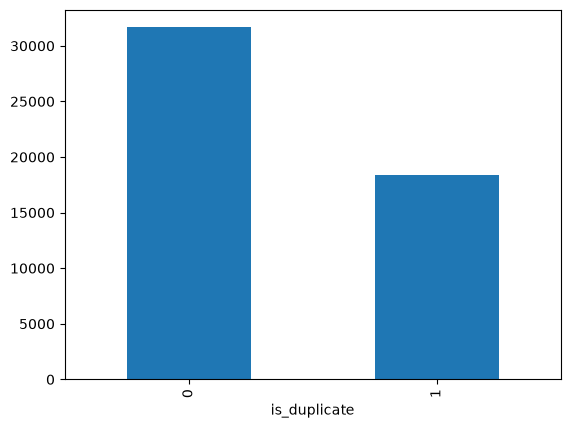

In [122]:
print(new_df["is_duplicate"].value_counts())
print((new_df["is_duplicate"].value_counts()/new_df["is_duplicate"].count())*100)
new_df['is_duplicate'].value_counts().plot(kind='bar')

In [123]:
qid = pd.Series(new_df['qid1'].tolist() + new_df['qid2'].tolist())
print('Number of unique questions',np.unique(qid).shape[0])
x = qid.value_counts()>1
print('Number of questions getting repeated',x[x].shape[0])

Number of unique questions 99528
Number of questions getting repeated 396


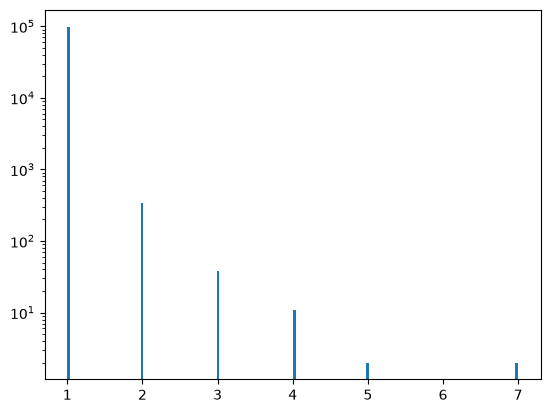

In [124]:

plt.hist(qid.value_counts().values,bins=160)
plt.yscale('log')
plt.show()

In [125]:
new_df['q1_len'] = new_df['question1'].str.len() 
new_df['q2_len'] = new_df['question2'].str.len()

In [126]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len
29642,29642,59092,59093,What are the top 5 most dangerous cities in th...,What are the most dangerous US cities? Why are...,1,96,65
330510,330510,648141,648142,How can Hillary Clinton be allowed to take mon...,Should we be concerned that Hillary Clinton go...,1,74,114
84867,84867,168554,168555,What if someone mistakenly has not mentioned f...,My father's annual income is 8 lakh. He is a g...,0,90,98
238929,238929,470644,470645,When companies outsource high ranking position...,Do founders need to be located in the same off...,0,102,74
358803,358803,702626,702627,How did the Kardashian family get famous?,"Who is more famous, Kim Kardashian or Kanye West?",0,41,49


In [127]:
new_df['q1_num_words'] = new_df['question1'].apply(lambda row: len(row.split(" ")))
new_df['q2_num_words'] = new_df['question2'].apply(lambda row: len(row.split(" ")))
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
29642,29642,59092,59093,What are the top 5 most dangerous cities in th...,What are the most dangerous US cities? Why are...,1,96,65,18,12
330510,330510,648141,648142,How can Hillary Clinton be allowed to take mon...,Should we be concerned that Hillary Clinton go...,1,74,114,12,19
84867,84867,168554,168555,What if someone mistakenly has not mentioned f...,My father's annual income is 8 lakh. He is a g...,0,90,98,14,20
238929,238929,470644,470645,When companies outsource high ranking position...,Do founders need to be located in the same off...,0,102,74,15,14
358803,358803,702626,702627,How did the Kardashian family get famous?,"Who is more famous, Kim Kardashian or Kanye West?",0,41,49,7,9


In [128]:
def common_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))    
    return len(w1 & w2)

In [129]:
new_df['word_common'] = new_df.apply(common_words, axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common
29642,29642,59092,59093,What are the top 5 most dangerous cities in th...,What are the most dangerous US cities? Why are...,1,96,65,18,12,8
330510,330510,648141,648142,How can Hillary Clinton be allowed to take mon...,Should we be concerned that Hillary Clinton go...,1,74,114,12,19,5
84867,84867,168554,168555,What if someone mistakenly has not mentioned f...,My father's annual income is 8 lakh. He is a g...,0,90,98,14,20,2
238929,238929,470644,470645,When companies outsource high ranking position...,Do founders need to be located in the same off...,0,102,74,15,14,3
358803,358803,702626,702627,How did the Kardashian family get famous?,"Who is more famous, Kim Kardashian or Kanye West?",0,41,49,7,9,1


In [130]:
def total_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))    
    return (len(w1) + len(w2))

In [131]:
new_df['word_total'] = new_df.apply(total_words, axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total
29642,29642,59092,59093,What are the top 5 most dangerous cities in th...,What are the most dangerous US cities? Why are...,1,96,65,18,12,8,28
330510,330510,648141,648142,How can Hillary Clinton be allowed to take mon...,Should we be concerned that Hillary Clinton go...,1,74,114,12,19,5,31
84867,84867,168554,168555,What if someone mistakenly has not mentioned f...,My father's annual income is 8 lakh. He is a g...,0,90,98,14,20,2,33
238929,238929,470644,470645,When companies outsource high ranking position...,Do founders need to be located in the same off...,0,102,74,15,14,3,29
358803,358803,702626,702627,How did the Kardashian family get famous?,"Who is more famous, Kim Kardashian or Kanye West?",0,41,49,7,9,1,16


minimum characters 2
maximum characters 334
average num of characters 59


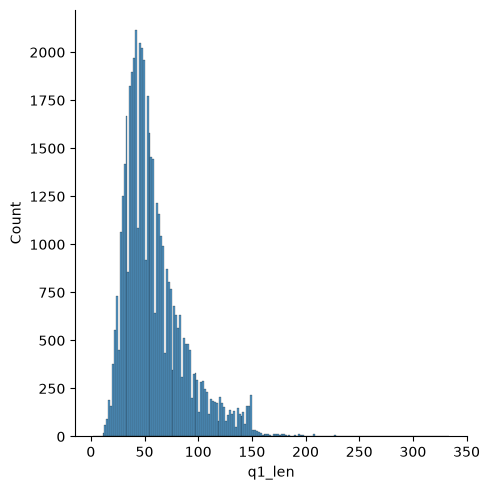

In [132]:
sns.displot(new_df['q1_len'])
print('minimum characters',new_df['q1_len'].min())
print('maximum characters',new_df['q1_len'].max())
print('average num of characters',int(new_df['q1_len'].mean()))

minimum characters 6
maximum characters 1151
average num of characters 60


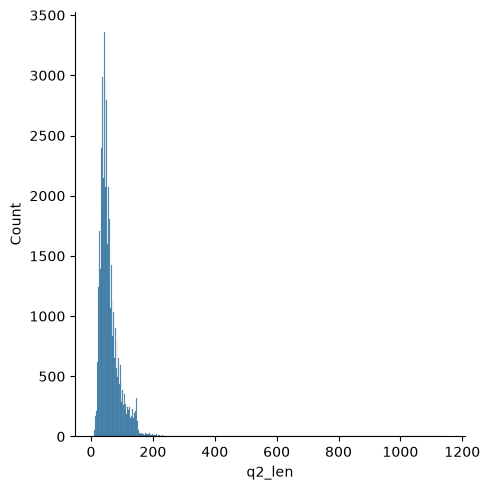

In [133]:
sns.displot(new_df['q2_len'])
print('minimum characters',new_df['q2_len'].min())
print('maximum characters',new_df['q2_len'].max())
print('average num of characters',int(new_df['q2_len'].mean()))

minimum words 1
maximum words 67
average num of words 10


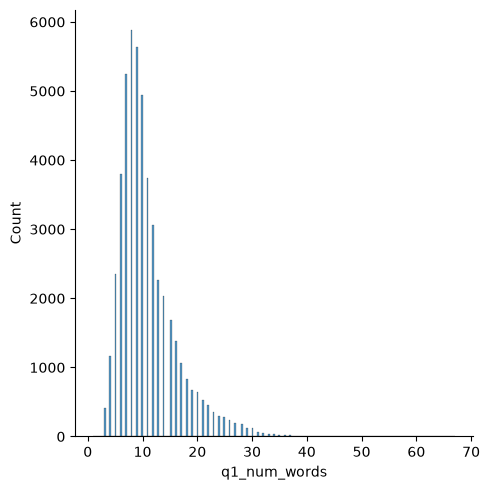

In [134]:
sns.displot(new_df['q1_num_words'])
print('minimum words',new_df['q1_num_words'].min())
print('maximum words',new_df['q1_num_words'].max())
print('average num of words',int(new_df['q1_num_words'].mean()))

minimum words 1
maximum words 237
average num of words 11


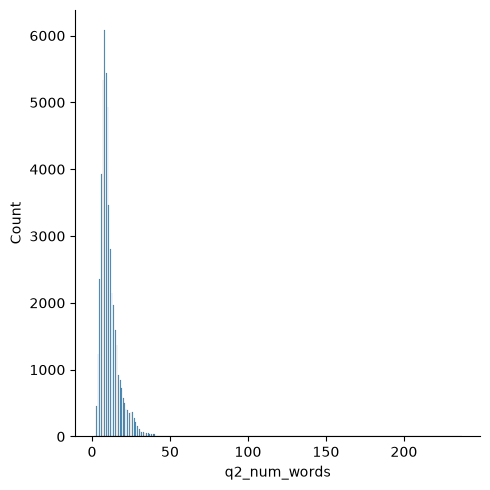

In [135]:
sns.displot(new_df['q2_num_words'])
print('minimum words',new_df['q2_num_words'].min())
print('maximum words',new_df['q2_num_words'].max())
print('average num of words',int(new_df['q2_num_words'].mean()))

C:\Users\himan\AppData\Local\Temp\ipykernel_11848\847226910.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_common'],label='non duplicate')
C:\Users\himan\AppData\Local\Temp\ipykernel_11848\847226910.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplo

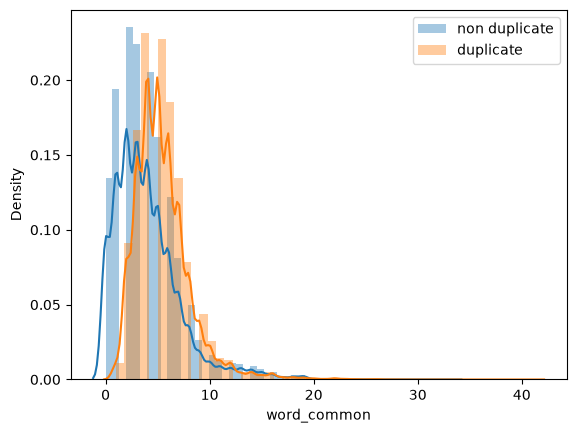

In [136]:
sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_common'],label='non duplicate')
sns.distplot(new_df[new_df['is_duplicate'] == 1]['word_common'],label='duplicate')
plt.legend()
plt.show()

C:\Users\himan\AppData\Local\Temp\ipykernel_11848\590203201.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_total'],label='non duplicate')
C:\Users\himan\AppData\Local\Temp\ipykernel_11848\590203201.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot

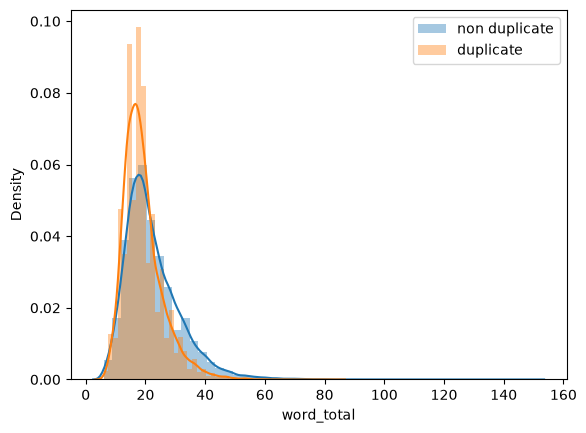

In [137]:
sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_total'],label='non duplicate')
sns.distplot(new_df[new_df['is_duplicate'] == 1]['word_total'],label='duplicate')
plt.legend()
plt.show()

In [138]:
new_df['word_share'] = round(new_df['word_common']/new_df['word_total'],2)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
29642,29642,59092,59093,What are the top 5 most dangerous cities in th...,What are the most dangerous US cities? Why are...,1,96,65,18,12,8,28,0.29
330510,330510,648141,648142,How can Hillary Clinton be allowed to take mon...,Should we be concerned that Hillary Clinton go...,1,74,114,12,19,5,31,0.16
84867,84867,168554,168555,What if someone mistakenly has not mentioned f...,My father's annual income is 8 lakh. He is a g...,0,90,98,14,20,2,33,0.06
238929,238929,470644,470645,When companies outsource high ranking position...,Do founders need to be located in the same off...,0,102,74,15,14,3,29,0.10
358803,358803,702626,702627,How did the Kardashian family get famous?,"Who is more famous, Kim Kardashian or Kanye West?",0,41,49,7,9,1,16,0.06


C:\Users\himan\AppData\Local\Temp\ipykernel_11848\2292000331.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_share'],label='non duplicate')
C:\Users\himan\AppData\Local\Temp\ipykernel_11848\2292000331.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distpl

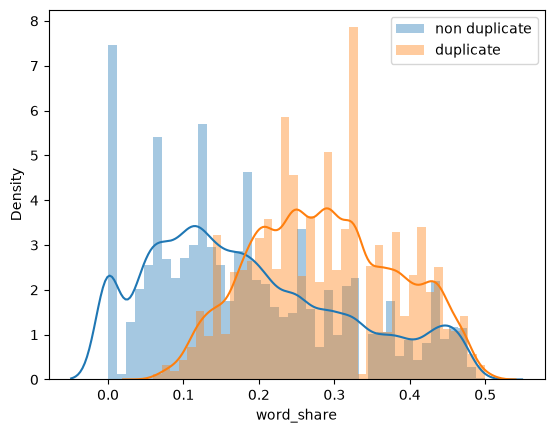

In [139]:
sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_share'],label='non duplicate')
sns.distplot(new_df[new_df['is_duplicate'] == 1]['word_share'],label='duplicate')
plt.legend()
plt.show()

In [140]:
ques_df = new_df[['question1','question2']]
ques_df.head()

,question1,question2
29642,What are the top 5 most dangerous cities in th...,What are the most dangerous US cities? Why are...
330510,How can Hillary Clinton be allowed to take mon...,Should we be concerned that Hillary Clinton go...
84867,What if someone mistakenly has not mentioned f...,My father's annual income is 8 lakh. He is a g...
238929,When companies outsource high ranking position...,Do founders need to be located in the same off...
358803,How did the Kardashian family get famous?,"Who is more famous, Kim Kardashian or Kanye West?"


In [141]:
final_df = new_df.drop(columns=['id','qid1','qid2','question1','question2'])
print(final_df.shape)
final_df.head()

(50000, 8)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
29642,1,96,65,18,12,8,28,0.29
330510,1,74,114,12,19,5,31,0.16
84867,0,90,98,14,20,2,33,0.06
238929,0,102,74,15,14,3,29,0.10
358803,0,41,49,7,9,1,16,0.06


In [142]:
from sklearn.feature_extraction.text import CountVectorizer
# merge texts
questions = list(ques_df['question1']) + list(ques_df['question2'])

cv = CountVectorizer(max_features=3000)
q1_arr, q2_arr = np.vsplit(cv.fit_transform(questions).toarray(),2)

In [143]:
temp_df.shape

(50000, 6001)

In [144]:
final_df = pd.concat([final_df, temp_df], axis=1)
print(final_df.shape)
final_df.head()

(50000, 6009)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,0,1,...,2991,2992,2993,2994,2995,2996,2997,2998,2999,is_duplicate
29642,1,96,65,18,12,8,28,0.29,0,0,...,0,0,0,0,0,0,0,0,0,1
330510,1,74,114,12,19,5,31,0.16,0,0,...,0,0,0,0,0,0,0,0,0,1
84867,0,90,98,14,20,2,33,0.06,0,0,...,0,0,0,0,0,0,0,0,0,0
238929,0,102,74,15,14,3,29,0.10,0,0,...,0,0,0,0,0,0,0,0,0,0
358803,0,41,49,7,9,1,16,0.06,0,0,...,0,0,0,0,0,0,0,0,0,0


In [145]:
final_df.columns

Index(['is_duplicate',       'q1_len',       'q2_len', 'q1_num_words',
       'q2_num_words',  'word_common',   'word_total',   'word_share',
                    0,              1,
       ...
                 2991,           2992,           2993,           2994,
                 2995,           2996,           2997,           2998,
                 2999, 'is_duplicate'],
      dtype='object', length=6009)

In [146]:
final_df = final_df.drop(final_df.columns[0], axis=1)
final_df.columns

Index([      'q1_len',       'q2_len', 'q1_num_words', 'q2_num_words',
        'word_common',   'word_total',   'word_share',              0,
                    1,              2,
       ...
                 2990,           2991,           2992,           2993,
                 2994,           2995,           2996,           2997,
                 2998,           2999],
      dtype='object', length=6007)

In [147]:
final_df.shape

(50000, 6007)

In [148]:
'is_duplicate' in final_df.columns

False

In [149]:
final_df['is_duplicate'] = new_df['is_duplicate']

In [159]:

print(final_df.shape)
final_df

(50000, 6008)


,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,0,1,2,...,2991,2992,2993,2994,2995,2996,2997,2998,2999,is_duplicate
29642,96,65,18,12,8,28,0.29,0,0,0,...,0,0,0,0,0,0,0,0,0,1
330510,74,114,12,19,5,31,0.16,0,0,0,...,0,0,0,0,0,0,0,0,0,1
84867,90,98,14,20,2,33,0.06,0,0,0,...,0,0,0,0,0,0,0,0,0,0
238929,102,74,15,14,3,29,0.10,0,0,0,...,0,0,0,0,0,0,0,0,0,0
358803,41,49,7,9,1,16,0.06,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177124,54,47,10,9,2,19,0.11,0,0,0,...,0,0,0,0,0,0,0,0,0,0
16195,27,33,5,6,1,11,0.09,0,0,0,...,0,0,0,0,0,0,0,0,0,0
97260,30,47,6,10,2,16,0.12,0,0,0,...,0,0,0,0,0,0,0,0,0,1
97684,57,76,9,12,2,21,0.10,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [160]:
from sklearn.model_selection import train_test_split

X = final_df.drop(columns=['is_duplicate']).values
y = final_df['is_duplicate'].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1,
    stratify=y
)

In [161]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.7818

In [162]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)
y_pred = xgb.predict(X_test)
accuracy_score(y_test,y_pred)

0.7693